In [97]:
# Beneficiary + PDE merge

# Join prescription drug events to beneficiary demographics on DESYNPUF_ID (synthetic patient ID).
# - Beneficiary: one row per patient
# - PDE: one row per prescription fill (many rows per patient)

In [98]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path(".")  # run notebook from data/Sample 1

BENE_PATH = DATA_DIR / "DE1_0_2008_Beneficiary_Summary_File_Sample_1 2.csv"
PDE_PATH = DATA_DIR / "DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv"

PATIENT_ID = "DESYNPUF_ID"

In [99]:
beneficiary = pd.read_csv(BENE_PATH, dtype={PATIENT_ID: str})
pde = pd.read_csv(
    PDE_PATH,
    dtype={PATIENT_ID: str, "PDE_ID": str, "PROD_SRVC_ID": str},
    low_memory=False,
)

print(f"Beneficiary: {beneficiary.shape[0]:,} rows × {beneficiary.shape[1]} cols")
print(f"PDE:         {pde.shape[0]:,} rows × {pde.shape[1]} cols")
print(f"Unique {PATIENT_ID} in beneficiary: {beneficiary[PATIENT_ID].nunique():,}")
print(f"Unique {PATIENT_ID} in PDE:         {pde[PATIENT_ID].nunique():,}")

Beneficiary: 116,352 rows × 32 cols
PDE:         5,552,421 rows × 8 cols
Unique DESYNPUF_ID in beneficiary: 116,352
Unique DESYNPUF_ID in PDE:         99,538


In [100]:
# Left join: keep every prescription row; attach beneficiary columns
combined = pde.merge(beneficiary, on=PATIENT_ID, how="left", validate="many_to_one")

orphan_pde_ids = set(pde[PATIENT_ID]) - set(beneficiary[PATIENT_ID])
print(f"Combined: {combined.shape[0]:,} rows × {combined.shape[1]} cols")
print(f"PDE patient IDs not in beneficiary file: {len(orphan_pde_ids):,}")
combined.head()
combined.shape

Combined: 5,552,421 rows × 39 cols
PDE patient IDs not in beneficiary file: 0


(5552421, 39)

In [101]:
# Prescription events per patient (2008 beneficiary cohort vs 2008–2010 PDE)
pde_per_patient = pde.groupby(PATIENT_ID, observed=True).size().rename("n_prescriptions")

bene_patients = beneficiary[PATIENT_ID]
n_bene = bene_patients.nunique()

has_pde = bene_patients.isin(pde_per_patient.index)
n_with_pde = has_pde.sum()
n_no_pde = (~has_pde).sum()
n_exactly_1 = (pde_per_patient == 1).sum()

print(f"Patients in 2008 beneficiary file: {n_bene:,}")
print(f"Patients with 0 prescription events: {n_no_pde:,} ({100 * n_no_pde / n_bene:.1f}%)")
print(f"Patients with >=1 prescription event: {n_with_pde:,}")
print(f"Patients with exactly 1 prescription event: {n_exactly_1:,} ({100 * n_exactly_1 / n_bene:.1f}% of all; {100 * n_exactly_1 / n_with_pde:.1f}% of those with any PDE)")
print(f"Patients with 2+ prescription events: {(pde_per_patient > 1).sum():,}")

Patients in 2008 beneficiary file: 116,352
Patients with 0 prescription events: 16,814 (14.5%)
Patients with >=1 prescription event: 99,538
Patients with exactly 1 prescription event: 5,209 (4.5% of all; 5.2% of those with any PDE)
Patients with 2+ prescription events: 94,329


## Conditions & coverage for 0 vs 1 prescription patients

- **Chronic conditions**: columns `SP_ALZHDMTA` … `SP_STRKETIA` (1 = yes, 2 = no per CMS DE-SynPUF)
- **Part D coverage (column 12)**: `PLAN_CVRG_MOS_NUM` — months enrolled in a Part D plan in **2008**
- PDE counts are **2008–2010**, so some patients can have fills without 2008 Part D months on the summary file

In [102]:
import numpy as np

CONDITION_COLS = [
    "SP_ALZHDMTA", "SP_CHF", "SP_CHRNKIDN", "SP_CNCR", "SP_COPD",
    "SP_DEPRESSN", "SP_DIABETES", "SP_ISCHMCHT", "SP_OSTEOPRS",
    "SP_RA_OA", "SP_STRKETIA",
]
CONDITION_LABELS = {
    "SP_ALZHDMTA": "Alzheimer's",
    "SP_CHF": "CHF",
    "SP_CHRNKIDN": "Chronic kidney disease",
    "SP_CNCR": "Cancer",
    "SP_COPD": "COPD",
    "SP_DEPRESSN": "Depression",
    "SP_DIABETES": "Diabetes",
    "SP_ISCHMCHT": "Ischemic heart disease",
    "SP_OSTEOPRS": "Osteoporosis",
    "SP_RA_OA": "RA/Osteoarthritis",
    "SP_STRKETIA": "Stroke/TIA",
}
PART_D_COVERAGE_COL = "PLAN_CVRG_MOS_NUM"  # column 12 in the CSV

bene_analysis = beneficiary.copy()
bene_analysis["n_pde"] = bene_analysis[PATIENT_ID].map(pde_per_patient).fillna(0).astype(int)
bene_analysis["pde_group"] = np.select(
    [bene_analysis["n_pde"] == 0, bene_analysis["n_pde"] == 1],
    ["0 prescriptions", "1 prescription"],
    default="2+ prescriptions",
)

In [103]:
def condition_prevalence(df: pd.DataFrame, group: str) -> pd.DataFrame:
    rows = []
    for col in CONDITION_COLS:
        yes = (df[col] == 1).sum()
        rows.append({
            "group": group,
            "condition": CONDITION_LABELS[col],
            "patients_with_condition": yes,
            "pct": round(100 * yes / len(df), 1),
        })
    return pd.DataFrame(rows)

def coverage_summary(df: pd.DataFrame, group: str) -> pd.Series:
    plan = df[PART_D_COVERAGE_COL]
    return pd.Series({
        "group": group,
        "n_patients": len(df),
        "part_d_months_mean": round(plan.mean(), 1),
        "part_d_months_median": plan.median(),
        "no_part_d_coverage_0_mos": int((plan == 0).sum()),
        "no_part_d_coverage_pct": round(100 * (plan == 0).mean(), 1),
        "any_part_d_coverage_pct": round(100 * (plan > 0).mean(), 1),
        "full_year_part_d_12_mos_pct": round(100 * (plan == 12).mean(), 1),
        "part_b_smi_0_mos_pct": round(100 * (df["BENE_SMI_CVRAGE_TOT_MONS"] == 0).mean(), 1),
        "part_a_hi_0_mos_pct": round(100 * (df["BENE_HI_CVRAGE_TOT_MONS"] == 0).mean(), 1),
    })

condition_table = pd.concat(
    [
        condition_prevalence(bene_analysis[bene_analysis.pde_group == g], g)
        for g in ["0 prescriptions", "1 prescription", "2+ prescriptions"]
    ],
    ignore_index=True,
)

for g in ["0 prescriptions", "1 prescription"]:
    sub = bene_analysis[bene_analysis.pde_group == g]
    print(
        f"{g}: any chronic condition = {sub[CONDITION_COLS].eq(1).any(axis=1).mean()*100:.1f}%  "
        f"| avg conditions per patient = {sub[CONDITION_COLS].eq(1).sum(axis=1).mean():.2f}"
    )

coverage_table = pd.DataFrame(
    [coverage_summary(bene_analysis[bene_analysis.pde_group == g], g) for g in ["0 prescriptions", "1 prescription", "2+ prescriptions"]]
)

display(condition_table.pivot(index="condition", columns="group", values="pct"))
display(coverage_table.set_index("group"))

0 prescriptions: any chronic condition = 20.0%  | avg conditions per patient = 0.59
1 prescription: any chronic condition = 76.2%  | avg conditions per patient = 2.31


group,0 prescriptions,1 prescription,2+ prescriptions
condition,,,
Alzheimer's,4.4,16.6,22.1
CHF,7.4,29.4,32.2
COPD,2.8,11.5,15.6
Cancer,2.6,9.0,6.9
Chronic kidney disease,3.6,15.0,18.3
Depression,4.5,17.3,24.6
Diabetes,10.1,40.1,42.7
Ischemic heart disease,13.0,50.7,46.8
Osteoporosis,5.6,21.5,19.2


,n_patients,part_d_months_mean,part_d_months_median,no_part_d_coverage_0_mos,no_part_d_coverage_pct,any_part_d_coverage_pct,full_year_part_d_12_mos_pct,part_b_smi_0_mos_pct,part_a_hi_0_mos_pct
group,,,,,,,,,
0 prescriptions,16814,1.4,0.0,14504,86.3,13.7,10.1,36.5,3.5
1 prescription,5209,0.6,0.0,4899,94.0,6.0,3.8,7.9,7.6
2+ prescriptions,94329,8.1,12.0,27894,29.6,70.4,63.6,5.0,4.6


## Single-prescription patients: fill timing & supply vs chronic conditions

Patients with **exactly one** PDE row (2008–2010). Each person has one fill, so *avg quantity* and *avg days supplied* are that fill's `QTY_DSPNSD_NUM` and `DAYS_SUPLY_NUM`. `SRVC_DT` is compared by calendar year and by whether each `SP_*` condition flag is yes (1) vs no (2).

In [104]:
one_pde_ids = pde_per_patient[pde_per_patient == 1].index
one_fill = pde[pde[PATIENT_ID].isin(one_pde_ids)].merge(
    beneficiary[[PATIENT_ID] + CONDITION_COLS],
    on=PATIENT_ID,
    how="left",
    validate="one_to_one",
)

one_fill["SRVC_DT"] = pd.to_datetime(one_fill["SRVC_DT"], format="%Y%m%d")
one_fill["SRVC_YEAR"] = one_fill["SRVC_DT"].dt.year
one_fill["n_conditions"] = one_fill[CONDITION_COLS].eq(1).sum(axis=1)

print(f"Patients with exactly 1 prescription: {len(one_fill):,}")
print(
    f"Quantity dispensed — mean: {one_fill.QTY_DSPNSD_NUM.mean():.1f}, median: {one_fill.QTY_DSPNSD_NUM.median():.0f}"
)
print(
    f"Days supplied — mean: {one_fill.DAYS_SUPLY_NUM.mean():.1f}, median: {one_fill.DAYS_SUPLY_NUM.median():.0f}"
)
print("Fills by service year:")
print(one_fill.SRVC_YEAR.value_counts().sort_index())

Patients with exactly 1 prescription: 5,209
Quantity dispensed — mean: 49.9, median: 30
Days supplied — mean: 34.7, median: 30
Fills by service year:
SRVC_YEAR
2008     367
2009    2042
2010    2800
Name: count, dtype: int64


In [105]:
def compare_fill_by_condition(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in CONDITION_COLS:
        name = CONDITION_LABELS[col]
        for flag, label in [(1, "has condition"), (2, "no condition")]:
            sub = df[df[col] == flag]
            rows.append({
                "condition": name,
                "group": label,
                "n": len(sub),
                "avg_qty_dispensed": round(sub.QTY_DSPNSD_NUM.mean(), 2),
                "avg_days_supplied": round(sub.DAYS_SUPLY_NUM.mean(), 1),
                "median_days_supplied": sub.DAYS_SUPLY_NUM.median(),
                "pct_srvc_2008": round(100 * (sub.SRVC_YEAR == 2008).mean(), 1),
                "pct_srvc_2009": round(100 * (sub.SRVC_YEAR == 2009).mean(), 1),
                "pct_srvc_2010": round(100 * (sub.SRVC_YEAR == 2010).mean(), 1),
            })
    return pd.DataFrame(rows)

fill_vs_condition = compare_fill_by_condition(one_fill)

# Wide view: has condition vs no condition
for metric in ["avg_qty_dispensed", "avg_days_supplied"]:
    display(
        fill_vs_condition.pivot(index="condition", columns="group", values=metric)
    )

display(
    fill_vs_condition.pivot(
        index="condition",
        columns="group",
        values=["pct_srvc_2008", "pct_srvc_2009", "pct_srvc_2010"],
    )
)

print("By total number of chronic conditions (SP_* = 1):")
display(
    one_fill.groupby("n_conditions", observed=True)
    .agg(
        n=(PATIENT_ID, "count"),
        avg_qty=("QTY_DSPNSD_NUM", "mean"),
        avg_days=("DAYS_SUPLY_NUM", "mean"),
        median_days=("DAYS_SUPLY_NUM", "median"),
        pct_srvc_2010=("SRVC_YEAR", lambda s: round(100 * (s == 2010).mean(), 1)),
    )
    .round(1)
)

group,has condition,no condition
condition,,
Alzheimer's,50.06,49.93
CHF,50.55,49.70
COPD,51.52,49.74
Cancer,49.29,50.01
Chronic kidney disease,46.99,50.47
Depression,48.79,50.19
Diabetes,49.43,50.30
Ischemic heart disease,50.22,49.67
Osteoporosis,49.18,50.16


group,has condition,no condition
condition,,
Alzheimer's,34.4,34.8
CHF,35.3,34.5
COPD,34.7,34.7
Cancer,33.1,34.9
Chronic kidney disease,34.2,34.8
Depression,36.1,34.5
Diabetes,35.3,34.4
Ischemic heart disease,35.2,34.2
Osteoporosis,34.2,34.9


pct_srvc_2008              pct_srvc_2009               \
group                  has condition no condition has condition no condition   
condition                                                                      
Alzheimer's                      8.3          6.8          38.2         39.4   
CHF                              7.8          6.7          40.5         38.7   
COPD                             8.7          6.8          39.7         39.1   
Cancer                           7.5          7.0          43.9         38.7   
Chronic kidney disease           7.4          7.0          42.6         38.6   
Depression                       8.2          6.8          42.2         38.6   
Diabetes                         7.4          6.8          41.2         37.9   
Ischemic heart disease           7.3          6.7          40.9         37.4   
Osteoporosis                     7.4          6.9          40.0         39.0   
RA/Osteoarthritis                7.1          7.0          40.3         39.0   
Stroke/TIA                      10.2          7.0          40.9         39.2   

                       pct_srvc_2010               
group                  has condition no condition  
condition                                          
Alzheimer's                     53.4         53.8  
CHF                             51.8         54.6  
COPD                            51.6         54.0  
Cancer                          48.6         54.3  
Chronic kidney disease          49.9         54.4  
Depression                      49.6         54.6  
Diabetes                        51.5         55.3  
Ischemic heart disease          51.7         55.8  
Osteoporosis                    52.5         54.1  
RA/Osteoarthritis               52.7         54.0  
Stroke/TIA                      48.9         53.9

By total number of chronic conditions (SP_* = 1):


,n,avg_qty,avg_days,median_days,pct_srvc_2010
n_conditions,,,,,
0,1238,49.8,33.8,30.0,58.5
1,1020,51.6,35.1,30.0,53.5
2,912,49.2,34.2,30.0,52.3
3,681,49.3,35.5,30.0,52.9
4,508,51.0,36.1,30.0,50.0
5,379,48.3,35.6,30.0,55.9
6,227,46.3,35.7,30.0,47.1
7,127,55.7,33.2,30.0,55.1
8,74,47.2,33.9,30.0,41.9


## Data cleaning (for adherence / heatmap analysis)

Applied before refill heatmaps:

1. **Remove zero-fill patients** — no PDE rows in 2008–2010  
2. **Remove single-fill patients** — only one prescription event (not enough for refill behavior)  
3. **Remove deaths in 2008** — `BENE_DEATH_DT` year = 2008 (partial-year exposure)

Earlier cells above use the **raw** cohort for exploratory analysis of excluded groups.


In [106]:
# --- Apply cleaning filters (creates beneficiary_clean / pde_clean for heatmaps) ---
PATIENT_ID = "DESYNPUF_ID"

pde_refill_counts = pde.groupby(PATIENT_ID, observed=True).size().rename("n_refills")

beneficiary_clean = beneficiary.copy()
beneficiary_clean["n_refills"] = beneficiary_clean[PATIENT_ID].map(pde_refill_counts).fillna(0).astype(int)
beneficiary_clean["death_year"] = (beneficiary_clean["BENE_DEATH_DT"] // 10_000).astype("Int64")

n_start = len(beneficiary_clean)
n_zero = (beneficiary_clean["n_refills"] == 0).sum()
n_single = (beneficiary_clean["n_refills"] == 1).sum()
n_died_2008 = (
    beneficiary_clean["BENE_DEATH_DT"].notna()
    & (beneficiary_clean["death_year"] == 2008)
).sum()

keep = (
    (beneficiary_clean["n_refills"] >= 2)
    & ~(
        beneficiary_clean["BENE_DEATH_DT"].notna()
        & (beneficiary_clean["death_year"] == 2008)
    )
)
beneficiary_clean = beneficiary_clean.loc[keep].drop(columns=["n_refills", "death_year"])
clean_ids = set(beneficiary_clean[PATIENT_ID])
pde_clean = pde[pde[PATIENT_ID].isin(clean_ids)].copy()

print("=== Cleaning audit ===")
print(f"Beneficiary patients — start: {n_start:,}")
print(f"  Removed zero-fill:     {n_zero:,}")
print(f"  Removed single-fill:   {n_single:,}")
print(f"  Removed died in 2008:  {n_died_2008:,}")
print(f"  Remaining patients:    {len(beneficiary_clean):,}")
print(f"PDE rows — start: {len(pde):,} | after: {len(pde_clean):,}")
print(f"Min refills in cleaned cohort: {pde_clean.groupby(PATIENT_ID).size().min()}")



=== Cleaning audit ===
Beneficiary patients — start: 116,352
  Removed zero-fill:     16,814
  Removed single-fill:   5,209
  Removed died in 2008:  1,814
  Remaining patients:    93,559
PDE rows — start: 5,552,421 | after: 5,534,042
Min refills in cleaned cohort: 2


## Refill heatmaps — 5 research questions

| # | Question | Heatmap |
|---|----------|---------|
| 1 | Does **medication cost** affect refill frequency? | Avg `TOT_RX_CST_AMT` per fill vs refill-count bin |
| 2 | Are **chronic conditions** related to refills? | Condition flags vs refill bin (% prevalence + counts) |
| 3 | Is **product ID** (`PROD_SRVC_ID`) related to refills? | Top 30 mode drugs; **row-normalized %** in each refill bin |
| 4 | Is **age** (2008) related to refills? | Age group vs refill bin (**row-normalized %**) |
| 5 | Is **gender** related to refills? | Sex vs refill bin |

**Refills** = PDE row count per patient (2008–2010), **cleaned cohort** (>=2 refills, no 2008 deaths). Run load + cleaning cells first.



In [107]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

CONDITION_COLS = [
    "SP_ALZHDMTA", "SP_CHF", "SP_CHRNKIDN", "SP_CNCR", "SP_COPD",
    "SP_DEPRESSN", "SP_DIABETES", "SP_ISCHMCHT", "SP_OSTEOPRS",
    "SP_RA_OA", "SP_STRKETIA",
]
CONDITION_LABELS = {
    "SP_ALZHDMTA": "Alzheimer's",
    "SP_CHF": "CHF",
    "SP_CHRNKIDN": "Chronic kidney disease",
    "SP_CNCR": "Cancer",
    "SP_COPD": "COPD",
    "SP_DEPRESSN": "Depression",
    "SP_DIABETES": "Diabetes",
    "SP_ISCHMCHT": "Ischemic heart disease",
    "SP_OSTEOPRS": "Osteoporosis",
    "SP_RA_OA": "RA/Osteoarthritis",
    "SP_STRKETIA": "Stroke/TIA",
}

# Cleaned cohort only (>=2 refills, no 2008 deaths)
REFILL_BINS = [2, 6, 21, 51, 101, 10_000]
REFILL_LABELS = ["2-5", "6-20", "21-50", "51-100", "100+"]

pde_patient = pde_clean.groupby(PATIENT_ID, observed=True).agg(
    n_refills=(PATIENT_ID, "count"),
    total_rx_cost=("TOT_RX_CST_AMT", "sum"),
    avg_rx_cost=("TOT_RX_CST_AMT", "mean"),
    top_prod_srvc_id=("PROD_SRVC_ID", lambda s: s.mode().iloc[0] if len(s) else pd.NA),
)

patients = beneficiary_clean.copy()
patients["birth_year"] = (patients["BENE_BIRTH_DT"] // 10_000).astype(int)
patients["age_2008"] = 2008 - patients["birth_year"]
patients["sex_label"] = patients["BENE_SEX_IDENT_CD"].map({1: "Male", 2: "Female"})
#sums the number of conditions for each patient
patients["n_conditions"] = patients[CONDITION_COLS].eq(1).sum(axis=1)

patients = patients.merge(pde_patient, on=PATIENT_ID, how="left", validate="one_to_one")
patients["total_rx_cost"] = patients["total_rx_cost"].fillna(0)
patients["avg_rx_cost"] = patients["avg_rx_cost"].fillna(0)

patients["refill_bin"] = pd.cut(
    patients["n_refills"],
    bins=REFILL_BINS,
    labels=REFILL_LABELS,
    right=False,
    include_lowest=True,
)

cost_quintiles = pd.qcut(
    patients["avg_rx_cost"],
    q=5,
    duplicates="drop",
)
patients["cost_bin"] = cost_quintiles.apply(
    lambda x: f"${max(0, x.left):.0f}-${x.right:.0f}" if pd.notna(x) else x
)

age_bins = [0, 64, 69, 74, 79, 84, 120]
age_labels = ["<65", "65-69", "70-74", "75-79", "80-84", "85+"]
patients["age_bin"] = pd.cut(patients["age_2008"], bins=age_bins, labels=age_labels, right=True)

print(f"Cleaned cohort: {len(patients):,} patients | refills range: {patients.n_refills.min()}-{patients.n_refills.max()}")
print(
    f"Correlation — refills vs avg cost/fill: {patients['n_refills'].corr(patients['avg_rx_cost']):.2f} | "
    f"refills vs total cost: {patients['n_refills'].corr(patients['total_rx_cost']):.2f}"
)



Cleaned cohort: 93,559 patients | refills range: 2-256
Correlation — refills vs avg cost/fill: 0.16 | refills vs total cost: 0.93


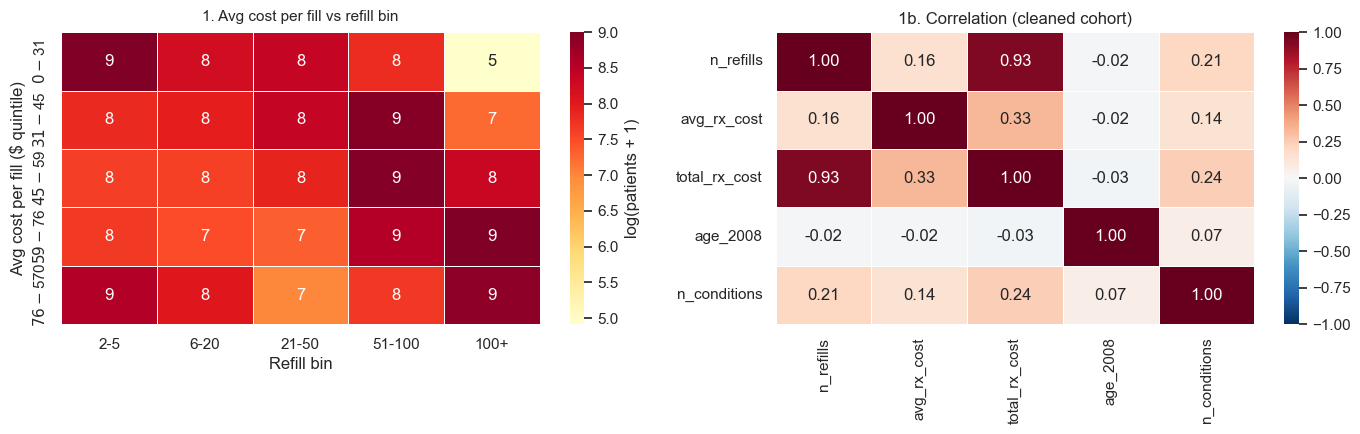

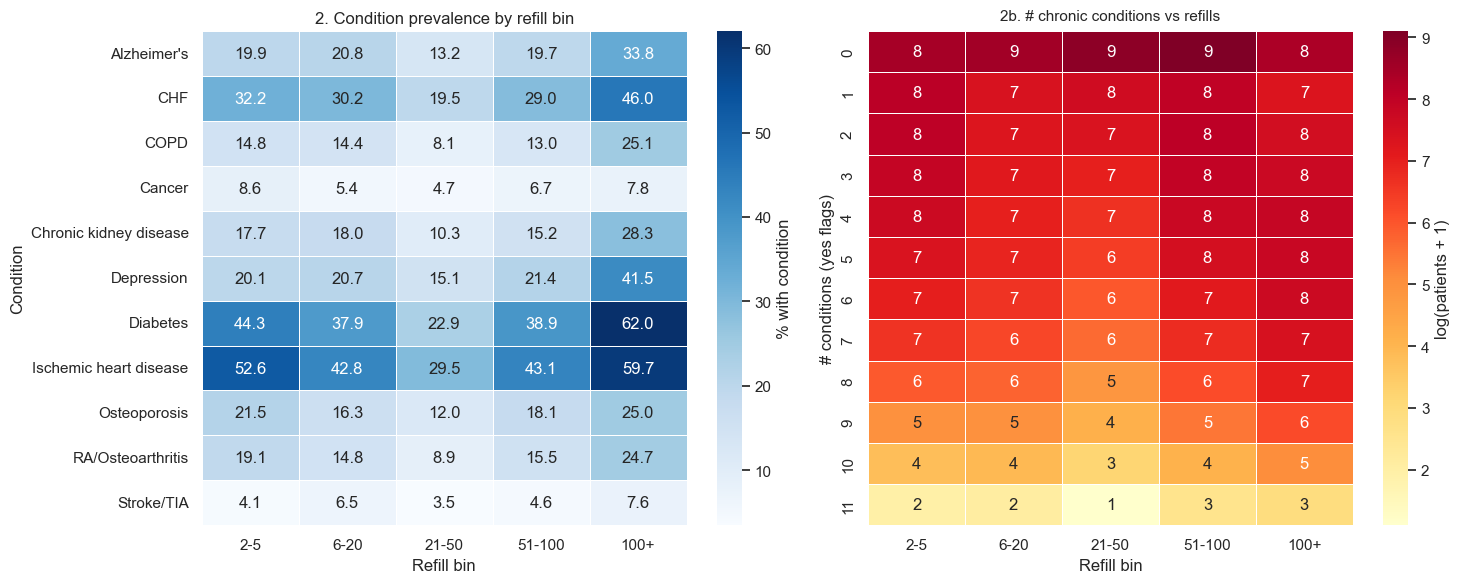

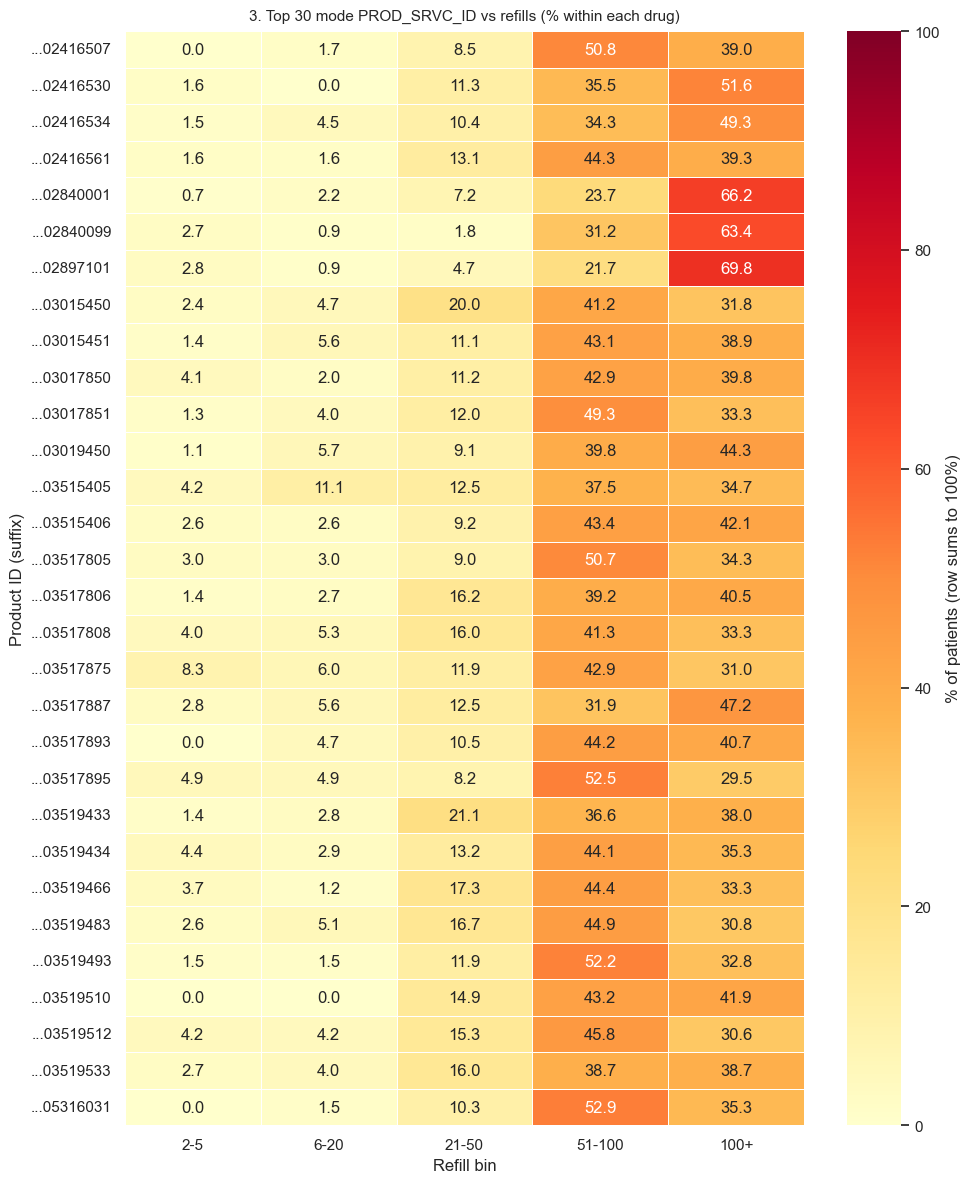

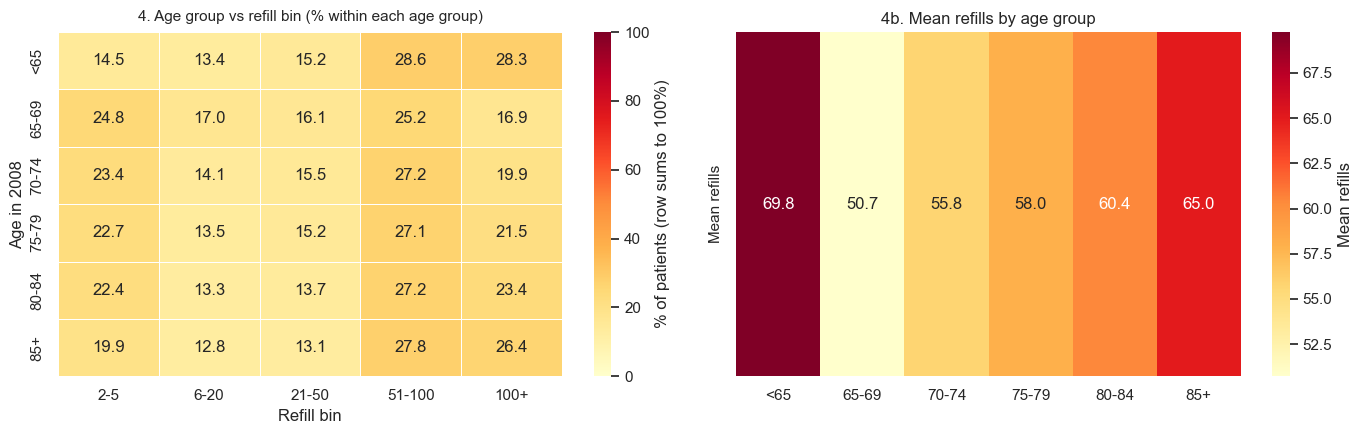

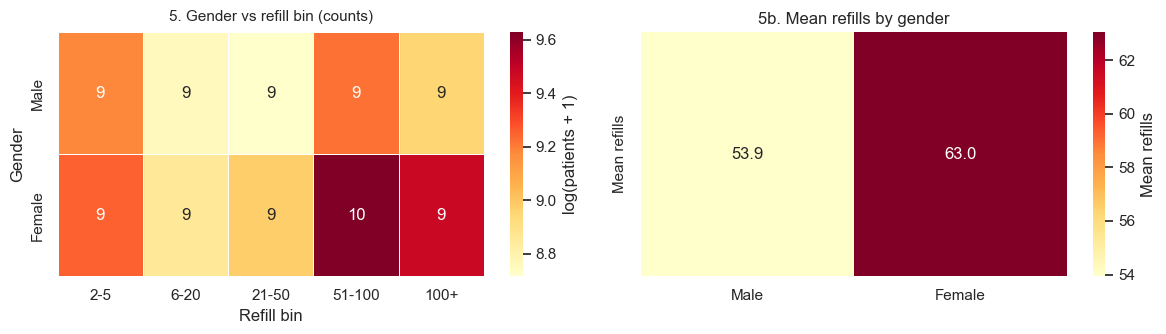

In [108]:
required = {"n_refills", "refill_bin", "top_prod_srvc_id", "cost_bin", "age_bin", "sex_label"}
missing = required - set(patients.columns)
if missing:
    raise RuntimeError(f"Run the cleaning + prep cells first. Missing columns: {missing}")

def _heatmap(ax, data, title, xlabel, ylabel, cmap="YlOrRd", fmt=".0f", cbar_label="Patients", log=False):
    plot = data.astype(float)
    if log:
        plot = np.log1p(plot)
        cbar_label = "log(patients + 1)"
    sns.heatmap(plot, annot=True, fmt=fmt, cmap=cmap, linewidths=0.5, ax=ax, cbar_kws={"label": cbar_label})
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


# --- Figure 1: Cost vs refills ---
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 4.5))

cost_refill = pd.crosstab(patients["cost_bin"], patients["refill_bin"]).reindex(columns=REFILL_LABELS)
_heatmap(axes1[0], cost_refill, "1. Avg cost per fill vs refill bin", "Refill bin", "Avg cost per fill ($ quintile)", log=True)

corr = patients[["n_refills", "avg_rx_cost", "total_rx_cost", "age_2008", "n_conditions"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes1[1], linewidths=0.5)
axes1[1].set_title("1b. Correlation (cleaned cohort)")
plt.tight_layout()
plt.show()

# --- Figure 2: Chronic conditions vs refills ---
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))

cond_pct_rows = []
for col in CONDITION_COLS:
    for rb in REFILL_LABELS:
        sub = patients[patients["refill_bin"] == rb]
        cond_pct_rows.append({
            "condition": CONDITION_LABELS[col],
            "refill_bin": rb,
            "pct": 100 * (sub[col] == 1).mean() if len(sub) else 0,
        })
cond_pct = pd.DataFrame(cond_pct_rows).pivot(index="condition", columns="refill_bin", values="pct")[REFILL_LABELS]
sns.heatmap(cond_pct, annot=True, fmt=".1f", cmap="Blues", ax=axes2[0], linewidths=0.5, cbar_kws={"label": "% with condition"})
axes2[0].set_title("2. Condition prevalence by refill bin")
axes2[0].set_xlabel("Refill bin")
axes2[0].set_ylabel("Chronic conditions")

ncond_refill = pd.crosstab(patients["n_conditions"], patients["refill_bin"]).reindex(columns=REFILL_LABELS)
_heatmap(axes2[1], ncond_refill, "2b. # chronic conditions vs refills", "Refill bin", "# chronic conditions", log=True)
plt.tight_layout()
plt.show()

# --- Figure 3: Product ID vs refills (row-normalized % per drug) ---
fig3, ax3 = plt.subplots(figsize=(10, 12))
top_n = 30
top_drugs = patients["top_prod_srvc_id"].value_counts().head(top_n).index
drug_subset = patients[patients["top_prod_srvc_id"].isin(top_drugs)]
drug_refill = pd.crosstab(drug_subset["top_prod_srvc_id"], drug_subset["refill_bin"]).reindex(columns=REFILL_LABELS)
drug_refill_pct = drug_refill.div(drug_refill.sum(axis=1), axis=0) * 100
drug_refill_pct.index = [f"...{str(i)[-8:]}" for i in drug_refill_pct.index]
sns.heatmap(
    drug_refill_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax3,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% of patients (row sums to 100%)"},
)
ax3.set_title(f"3. Top {top_n} mode PROD_SRVC_ID vs refills (% within each drug)", fontsize=11, pad=8)
ax3.set_xlabel("Refill bin")
ax3.set_ylabel("Product ID (suffix)")
plt.tight_layout()
plt.show()

# --- Figure 4: Age vs refills (row-normalized % per age group) ---
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 4.5))
age_refill = pd.crosstab(patients["age_bin"], patients["refill_bin"]).reindex(index=age_labels, columns=REFILL_LABELS)
age_refill_pct = age_refill.div(age_refill.sum(axis=1), axis=0) * 100
sns.heatmap(
    age_refill_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=axes4[0],
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% of patients (row sums to 100%)"},
)
axes4[0].set_title("4. Age group vs refill bin (% within each age group)", fontsize=11, pad=8)
axes4[0].set_xlabel("Refill bin")
axes4[0].set_ylabel("Age in 2008")

mean_refill_age = patients.groupby("age_bin", observed=True)["n_refills"].mean().reindex(age_labels)
mean_mat = pd.DataFrame([mean_refill_age.values], index=["Mean refills"], columns=age_labels)
sns.heatmap(mean_mat, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes4[1], cbar_kws={"label": "Mean refills"})
axes4[1].set_title("4b. Mean refills by age group")
plt.tight_layout()
plt.show()

# --- Figure 5: Gender vs refills ---
fig5, axes5 = plt.subplots(1, 2, figsize=(12, 3.5))
sex_refill = pd.crosstab(patients["sex_label"], patients["refill_bin"]).reindex(index=["Male", "Female"], columns=REFILL_LABELS)
_heatmap(axes5[0], sex_refill, "5. Gender vs refill bin (counts)", "Refill bin", "Gender", log=True)

mean_refill_sex = patients.groupby("sex_label", observed=True)["n_refills"].mean().reindex(["Male", "Female"])
mean_sex_mat = pd.DataFrame([mean_refill_sex.values], index=["Mean refills"], columns=["Male", "Female"])
sns.heatmap(mean_sex_mat, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes5[1], cbar_kws={"label": "Mean refills"})
axes5[1].set_title("5b. Mean refills by gender")
plt.tight_layout()
plt.show()




### Quick answers from the heatmaps

1. **Cost:** **Total** drug spend rises strongly with more refills (r ≈ 0.93). **Average cost per fill** is only weakly related (r ≈ 0.13)—refill count drives total cost more than expensive single prescriptions.
2. **Chronic conditions:** Higher refill bins show higher % with most conditions; patients with more `SP_*` flags cluster in higher refill columns.
3. **Product ID:** Row-normalized heatmap (% of each drug's patients in each refill bin). Compare **across columns** within a row—e.g. mass on the right = heavier refill behavior for that drug, not just more popular.
4. **Age:** Row-normalized heatmap shows each age group's refill mix (rows sum to 100%). Compare across columns—e.g. more % in high refill bins = heavier use for that age group. Panel 4b shows mean refills.
5. **Gender:** Females have higher mean refills (~53 vs ~42 for males); count heatmap shows more female patients in mid/high refill bins.
